# 🛍️ Customer Segmentation Using K-Means Clustering

## Minor Project

### Submitted By
**Name:** Priyanshu Dash

**College:** Kalinga Institute of Industrial Technology (KIIT)

**Branch:** Computer Science & Engineering

**Year:** 4th Year

**Roll Number:** AIML-A6/JN-10471

**Course:** Machine Learning - InternsElite

**Guide:** Abhishek Pandey

# 🎯 Project Objective

The objective of this project is to segment customers into different groups based on their purchasing behavior using the K-Means Clustering algorithm.

Customer segmentation helps businesses understand different types of customers and allows them to create personalized marketing strategies. By grouping customers with similar characteristics such as annual income and spending score, companies can improve customer satisfaction and maximize profits.

# 📚 Import Required Libraries

In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# 📂 Load the Dataset

In [4]:
# Load the dataset

df = pd.read_csv("Mall_Customers.csv")

# Display first five rows

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 🔍 Explore the Dataset

In [5]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
# Display statistical summary

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
# Check for missing values

df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [8]:
# Check duplicate records

df.duplicated().sum()

np.int64(0)

# 📊 Exploratory Data Analysis (EDA)

In [9]:
# Display dataset shape

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 200
Number of Columns : 5


In [10]:
# Display column names

df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [11]:
# Display first ten records

df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


# 📈 Data Visualization

In [12]:
# Import visualization library

import matplotlib.pyplot as plt

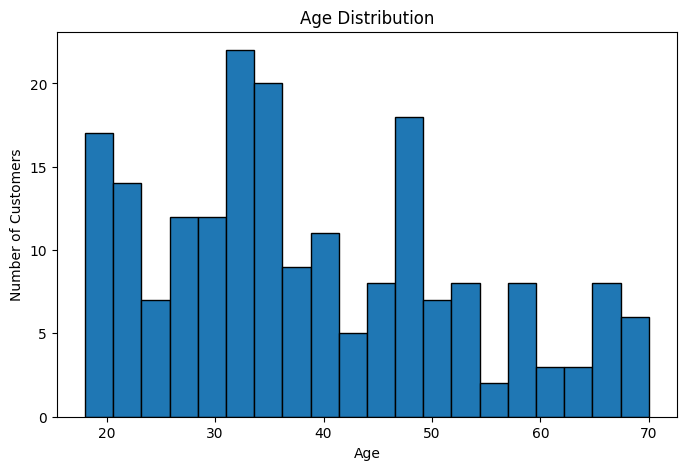

In [13]:
# Distribution of Customer Age

plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20, edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

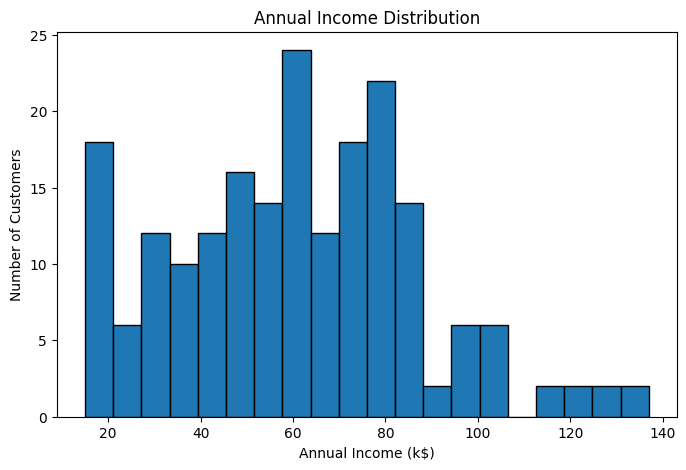

In [14]:
# Distribution of Annual Income

plt.figure(figsize=(8,5))

plt.hist(df["Annual Income (k$)"], bins=20, edgecolor="black")

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

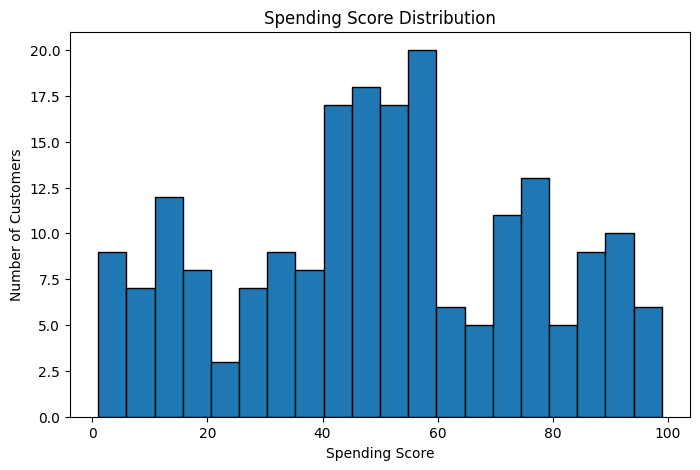

In [15]:
# Distribution of Spending Score

plt.figure(figsize=(8,5))

plt.hist(df["Spending Score (1-100)"], bins=20, edgecolor="black")

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

# 👨 Gender Distribution

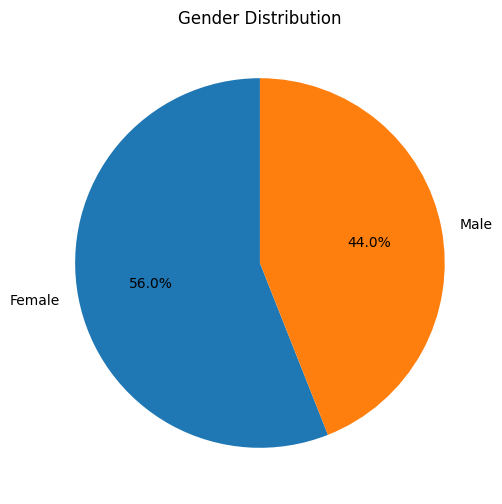

In [16]:
gender_count = df["Gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

# 💰 Relationship Between Annual Income and Spending Score

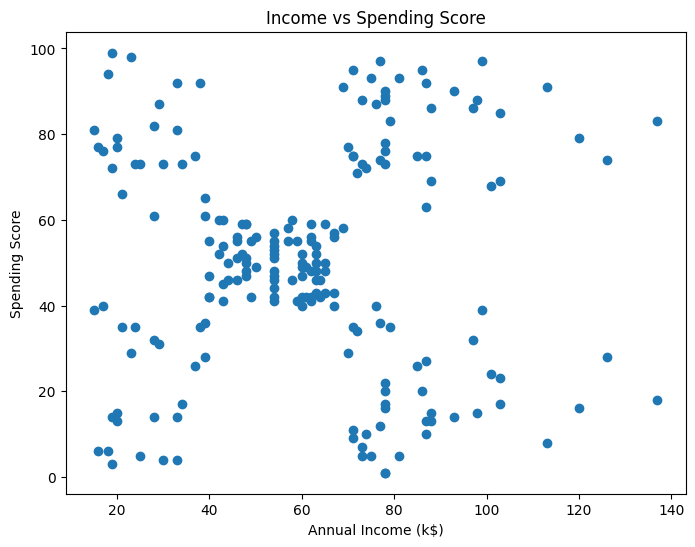

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.title("Income vs Spending Score")

plt.show()

# ⚙ Data Preprocessing

In [18]:
# Select features for clustering

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [19]:
# Standardize the data

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 📉 Finding the Optimal Number of Clusters (Elbow Method)

In [20]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

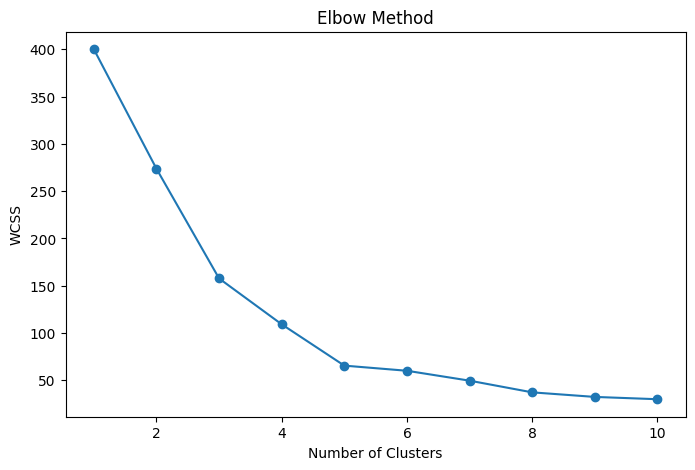

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

# 🤖 Build the K-Means Clustering Model

In [22]:
# Create the K-Means model with 5 clusters

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

# Train the model

y_kmeans = kmeans.fit_predict(X_scaled)

# 📊 Assign Cluster Labels to Customers

In [23]:
# Add cluster labels to the original dataset

df["Cluster"] = y_kmeans

# Display first five records

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


# 🎨 Visualize Customer Segments

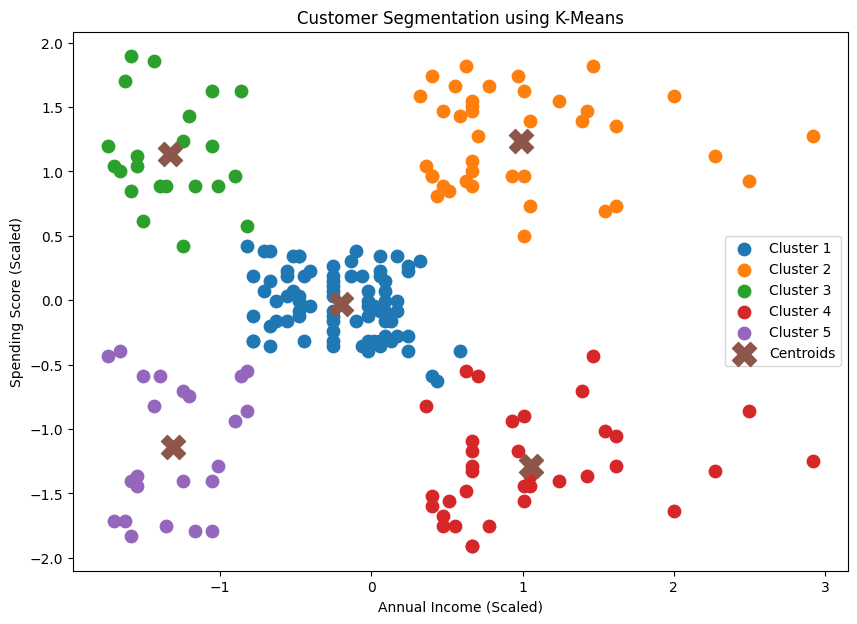

In [24]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_scaled[y_kmeans==0,0],
    X_scaled[y_kmeans==0,1],
    s=80,
    label="Cluster 1"
)

plt.scatter(
    X_scaled[y_kmeans==1,0],
    X_scaled[y_kmeans==1,1],
    s=80,
    label="Cluster 2"
)

plt.scatter(
    X_scaled[y_kmeans==2,0],
    X_scaled[y_kmeans==2,1],
    s=80,
    label="Cluster 3"
)

plt.scatter(
    X_scaled[y_kmeans==3,0],
    X_scaled[y_kmeans==3,1],
    s=80,
    label="Cluster 4"
)

plt.scatter(
    X_scaled[y_kmeans==4,0],
    X_scaled[y_kmeans==4,1],
    s=80,
    label="Cluster 5"
)

# Plot cluster centers

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")

plt.xlabel("Annual Income (Scaled)")

plt.ylabel("Spending Score (Scaled)")

plt.legend()

plt.show()

# 📋 Number of Customers in Each Cluster

In [25]:
df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,22
3,35
4,23


# 📊 Average Values of Each Customer Segment

In [26]:
df.groupby("Cluster")[["Age",
                       "Annual Income (k$)",
                       "Spending Score (1-100)"]].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


# 📈 Cluster-wise Customer Count

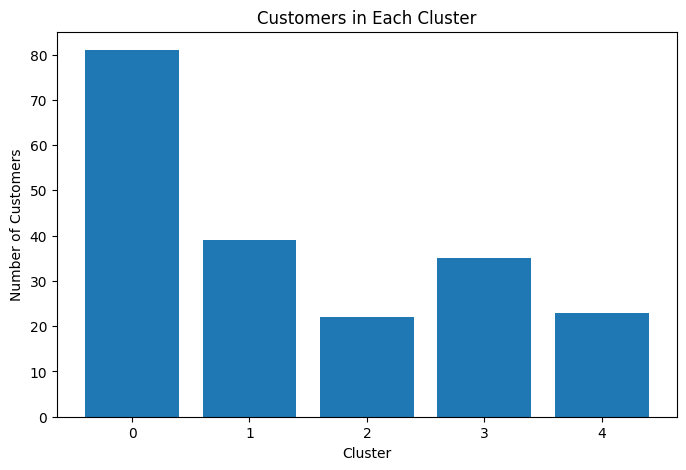

In [27]:
cluster_count = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(cluster_count.index,
        cluster_count.values)

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.title("Customers in Each Cluster")

plt.show()

In [28]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Calculate clustering evaluation metrics
silhouette = silhouette_score(X_scaled, y_kmeans)
davies_bouldin = davies_bouldin_score(X_scaled, y_kmeans)

print("Customer Segmentation Evaluation")
print("---------------------------------")
print("Silhouette Score       :", silhouette)
print("Davies-Bouldin Index   :", davies_bouldin)

Customer Segmentation Evaluation
---------------------------------
Silhouette Score       : 0.5546571631111091
Davies-Bouldin Index   : 0.5722356162263352


# 📝 Conclusion

This project successfully segmented mall customers into different groups using the K-Means Clustering algorithm.

The Elbow Method was used to determine the optimal number of clusters, and customers were grouped according to their Annual Income and Spending Score.

These customer segments can help businesses understand customer behavior, improve marketing strategies, increase customer satisfaction, and maximize business profits.

Customer segmentation is one of the most widely used applications of Unsupervised Machine Learning in retail and e-commerce industries.

# 🚀 Future Scope

Future improvements to this project may include:

- Using more customer features for clustering.
- Applying advanced clustering algorithms such as DBSCAN or Hierarchical Clustering.
- Developing an interactive dashboard using Streamlit or Gradio.
- Integrating real-time customer data for dynamic segmentation.